# Lambda Experiments

## Tranining

In [1]:
import sys
sys.path.append("..")

from source.system import SystemParams
from source.policy import NeuralPolicy

from source.utils import read_csv
from source.training import train_net

In [2]:
import torch
import os

EPOCHS       = 1000
LR           = 5e-4
WEIGHT_DECAY = 1e-5
BATCH_SIZE   = 1000
SEED_BASE    = 123
LAMBDA_COST  = [0.0, 0.1, 0.25, 0.5]
LAMBDA_DEMAND = 0.0
ALPHA_GRID   = 0.0
DEVICE       = torch.device("cpu")

params = SystemParams()
S0_single = torch.tensor([[0., 0., 100., 0.01]], device=DEVICE)

energy_prices = read_csv("../data/eprice_test.csv")
price_history = energy_prices[:params.T]
future_price = energy_prices[params.T:]

CHECKPOINT_DIR = "../checkpoints/lambda_experiments"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# Same initial weights for all lambda experiments
torch.manual_seed(SEED_BASE)
initial_policy = NeuralPolicy().to(DEVICE)
initial_state = {
    k: v.detach().cpu().clone()
    for k, v in initial_policy.state_dict().items()
}

for lambda_cost in LAMBDA_COST:

    print("=" * 50)
    print(f"Training: lambda={lambda_cost}")

    # Reset policy to the same initial weights
    policy = NeuralPolicy().to(DEVICE)
    policy.load_state_dict(initial_state)

    opt = torch.optim.AdamW(
        policy.parameters(),
        lr=LR,
        weight_decay=WEIGHT_DECAY
    )

    res = train_net(
        policy=policy,
        optimizer=opt,
        device=DEVICE,
        params=params,
        S0_single=S0_single,
        endog_history=price_history,
        future_endog=future_price,
        epochs=EPOCHS,
        lambda_cost=lambda_cost,
        lambda_demand=LAMBDA_DEMAND,
        alpha_grid=ALPHA_GRID,
        batch_size=BATCH_SIZE,
        seed_base=SEED_BASE,
        verbose=True
    )

    print(f"lambda: {lambda_cost}, best J: {res['best_J']}")

    filename = f"policy_lambda_{str(lambda_cost).replace('.', '_')}.pt"
    path = os.path.join(CHECKPOINT_DIR, filename)

    checkpoint = {
        "lambda_cost": lambda_cost,
        "alpha_grid": ALPHA_GRID,
        "best_J": res["best_J"],
        "policy_state_dict": res["best_state"],
        "J_train_hist": res["J_train_hist"],
        "J_eval_hist": res["J_eval_hist"],
        "seed_base": SEED_BASE,
        "epochs": EPOCHS,
        "batch_size": BATCH_SIZE,
        "lr": LR,
        "weight_decay": WEIGHT_DECAY,
    }

    if "best_epoch" in res:
        checkpoint["best_epoch"] = res["best_epoch"]

    torch.save(checkpoint, path)

    print(f"Saved best policy: {path}\n")

Training: lambda=0.0
[050] J_train=-8.8788 | J_eval(det)=-9.0103
[100] J_train=-12.4193 | J_eval(det)=-12.2605
[150] J_train=-15.9300 | J_eval(det)=-15.4137
[200] J_train=-18.2545 | J_eval(det)=-17.2446
[250] J_train=-20.0646 | J_eval(det)=-18.3851
[300] J_train=-21.5707 | J_eval(det)=-19.2243
[350] J_train=-22.5794 | J_eval(det)=-19.8580
[400] J_train=-23.5941 | J_eval(det)=-20.3875
[450] J_train=-24.5226 | J_eval(det)=-21.0588
[500] J_train=-25.6462 | J_eval(det)=-21.8963
[550] J_train=-26.0774 | J_eval(det)=-22.2285
[600] J_train=-26.2789 | J_eval(det)=-22.3496
[650] J_train=-26.9001 | J_eval(det)=-22.4259
[700] J_train=-27.2063 | J_eval(det)=-22.5122
[750] J_train=-27.2545 | J_eval(det)=-22.5904
[800] J_train=-27.2077 | J_eval(det)=-22.6792
[850] J_train=-27.3620 | J_eval(det)=-22.7055
[900] J_train=-27.7532 | J_eval(det)=-22.7399
[950] J_train=-27.5439 | J_eval(det)=-22.7875
[1000] J_train=-27.8585 | J_eval(det)=-22.8155

Training ready in 463.5s. Epoch: 996. Best J=-28.2324
lambd

## Traning convergence

In [3]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt

CHECKPOINT_DIR = "../checkpoints/lambda_experiments"
LAMBDA_COST = [0.0, 0.1, 0.25, 0.5]

checkpoints = {}

for lambda_cost in LAMBDA_COST:
    filename = f"policy_lambda_{str(lambda_cost).replace('.', '_')}.pt"
    path = os.path.join(CHECKPOINT_DIR, filename)

    ckpt = torch.load(path, map_location="cpu")
    checkpoints[lambda_cost] = ckpt

    print("=" * 50)
    print(f"lambda = {lambda_cost}")
    print(f"best_J = {ckpt['best_J']}")
    print(f"J_train_hist length = {len(ckpt['J_train_hist'])}")
    print(f"J_eval_hist length  = {len(ckpt['J_eval_hist'])}")

lambda = 0.0
best_J = -28.23244857788086
J_train_hist length = 1000
J_eval_hist length  = 20
lambda = 0.1
best_J = -25.385562896728516
J_train_hist length = 1000
J_eval_hist length  = 20
lambda = 0.25
best_J = -21.760150909423828
J_train_hist length = 1000
J_eval_hist length  = 20
lambda = 0.5
best_J = -18.585214614868164
J_train_hist length = 1000
J_eval_hist length  = 20


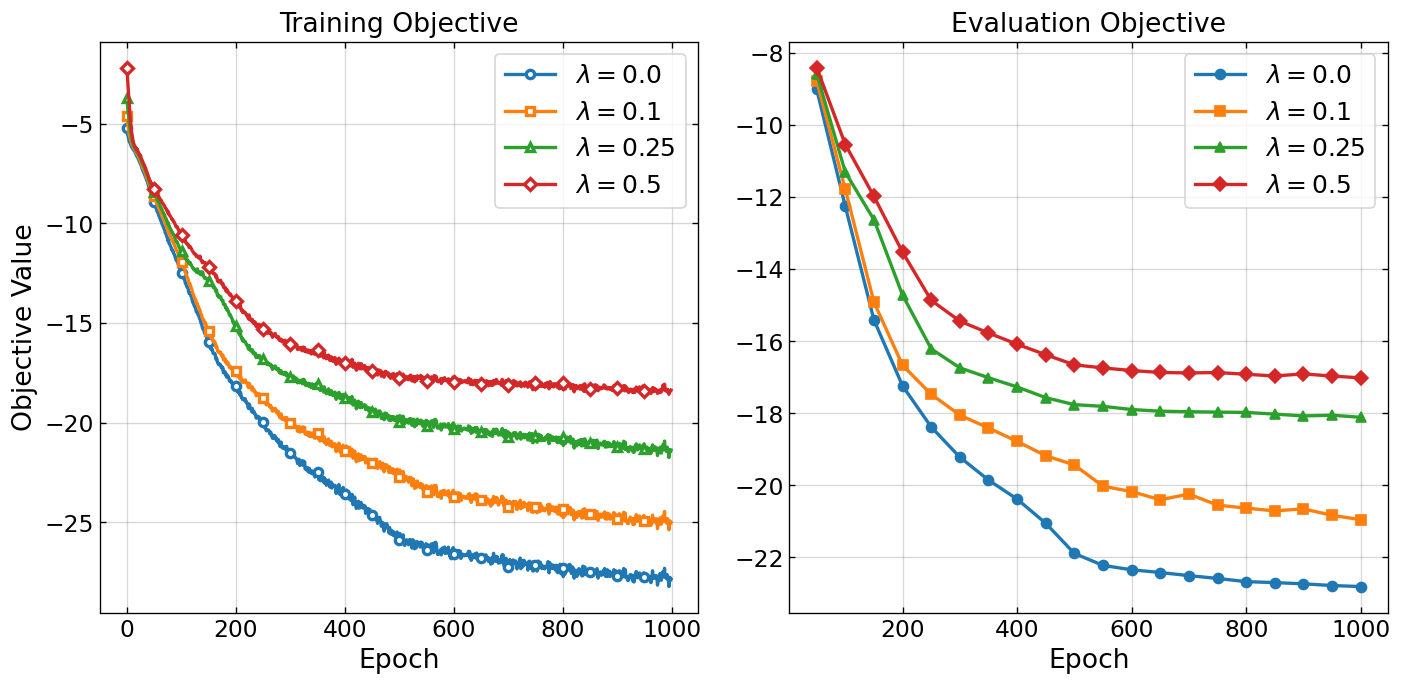

In [4]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("../styles/paper.mplstyle")

CHECKPOINT_DIR = "../checkpoints/lambda_experiments"
LAMBDA_COST = [0.0, 0.1, 0.25, 0.5]

fig, axs = plt.subplots(
    1, 2,
    figsize=(12, 6),
    sharey=False
)

markers = ["o", "s", "^", "D"]

for marker, lambda_cost in zip(markers, LAMBDA_COST):

    filename = f"policy_lambda_{str(lambda_cost).replace('.', '_')}.pt"
    path = os.path.join(CHECKPOINT_DIR, filename)

    ckpt = torch.load(path, map_location="cpu")

    J_train = ckpt["J_train_hist"]
    J_eval = ckpt["J_eval_hist"]

    eval_epochs = np.arange(50, len(J_train) + 1, 50)

    axs[0].plot(
        J_train,
        linestyle="-",
        marker=marker,
        markevery=50,
        markersize=5,
        linewidth=2,
        markerfacecolor="white",
        markeredgewidth=2,
        label=fr"$\lambda={lambda_cost}$"
    )

    axs[1].plot(
        eval_epochs,
        J_eval,
        linestyle="-",
        marker=marker,
        markersize=6,
        linewidth=2,
        label=fr"$\lambda={lambda_cost}$"
    )

axs[0].set_title("Training Objective")
axs[0].set_xlabel("Epoch")
axs[0].set_ylabel("Objective Value")
axs[0].grid(True, alpha=0.3)

axs[1].set_title("Evaluation Objective")
axs[1].set_xlabel("Epoch")
axs[1].grid(True, alpha=0.3)

axs[0].legend()
axs[1].legend()

plt.tight_layout()

plt.savefig(
    "../figures/lambda_experiments/training_evaluation_objective.pdf",
    bbox_inches="tight"
)

plt.savefig(
    "../figures/lambda_experiments/training_evaluation_objective.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Comparison

In [5]:
import sys
sys.path.append("..")

import torch
import os

from source.system import SystemParams
from source.simulation import sample_initial_state, rollout_trajectory
from source.stochastic_processes import make_price_function
from source.utils import read_csv
from source.policy import NeuralPolicy

DEVICE = torch.device("cpu")

POLICY_DIR = "../checkpoints/lambda_experiments"
ROLLOUT_DIR = "../checkpoints/rollouts"
os.makedirs(ROLLOUT_DIR, exist_ok=True)

LAMBDA_COST = [0.0, 0.1, 0.25, 0.5]

ALPHA_GRID = 0.0
BATCH_SIZE = 1000
SEED_BASE = 123

params = SystemParams()

S0 = sample_initial_state(
    batch_size=BATCH_SIZE,
    params=params,
    device=DEVICE,
    seed=SEED_BASE
)

energy_prices = read_csv("../data/eprice_test.csv")
price_history = energy_prices[:params.T]
future_price = energy_prices[params.T:]



rollout_results = {}

for lambda_cost in LAMBDA_COST:

    next_price_fn_eval = make_price_function(
        price_history,
        future_price,
        params
    )

    print("=" * 50)
    print(f"Rollout: lambda={lambda_cost}")

    filename = f"policy_lambda_{str(lambda_cost).replace('.', '_')}.pt"
    path = os.path.join(POLICY_DIR, filename)

    ckpt = torch.load(path, map_location=DEVICE)

    policy = NeuralPolicy().to(DEVICE)
    policy.load_state_dict(ckpt["policy_state_dict"])
    policy.eval()

    with torch.no_grad():
        history = rollout_trajectory(
            policy=policy,
            S0=S0,
            lambda_cost=lambda_cost,
            lambda_demand=0.0,
            alpha_grid=ALPHA_GRID,
            params=params,
            next_price_fn=next_price_fn_eval,
            stochastic=True,
            seed=SEED_BASE,
            device=DEVICE,
        )

    lambda_key = str(lambda_cost)

    rollout_results[lambda_key] = history

    print(f"J_episode: {history['J_episode']}")

rollout_path = os.path.join(ROLLOUT_DIR, "lambda_experiment.pt")

torch.save(rollout_results, rollout_path)

print(f"\nSaved rollouts: {rollout_path}")

Rollout: lambda=0.0
J_episode: -27.34307861328125
Rollout: lambda=0.1
J_episode: -24.419897079467773
Rollout: lambda=0.25
J_episode: -20.499433517456055
Rollout: lambda=0.5
J_episode: -17.190603256225586

Saved rollouts: ../checkpoints/rollouts\lambda_experiment.pt


In [6]:
import sys
sys.path.append("..")

import torch

import matplotlib.pyplot as plt

plt.style.use("../styles/paper.mplstyle")

from source.plotting import *


rollout_results = torch.load("../checkpoints/rollouts/lambda_experiment.pt")


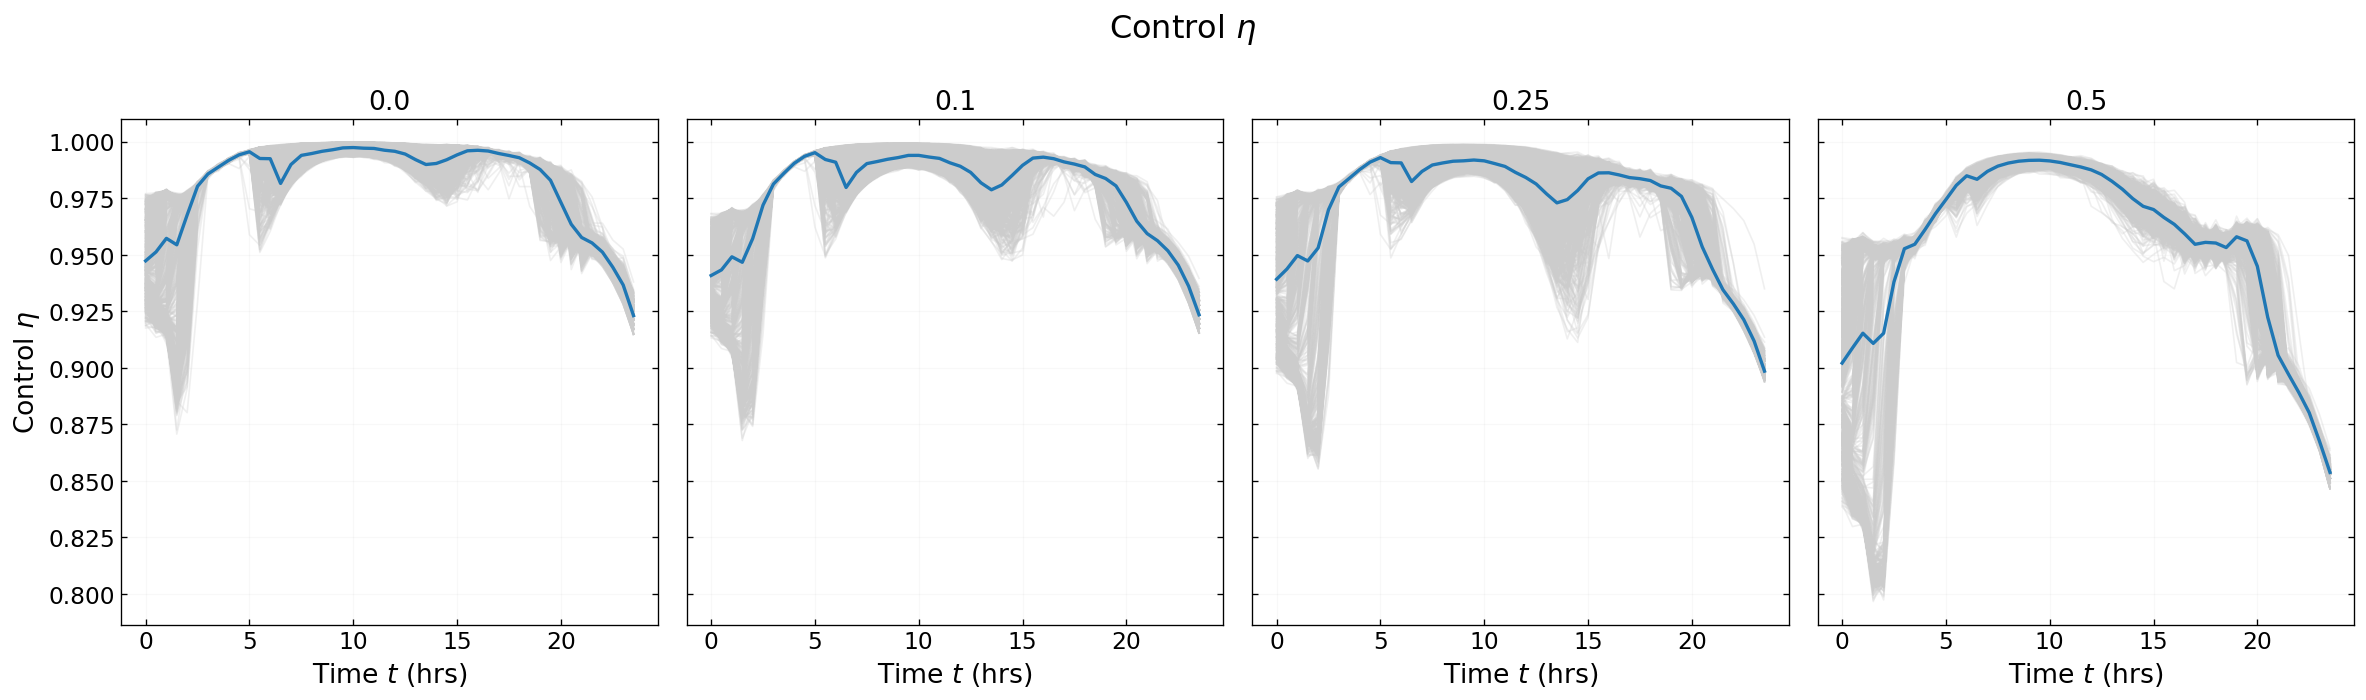

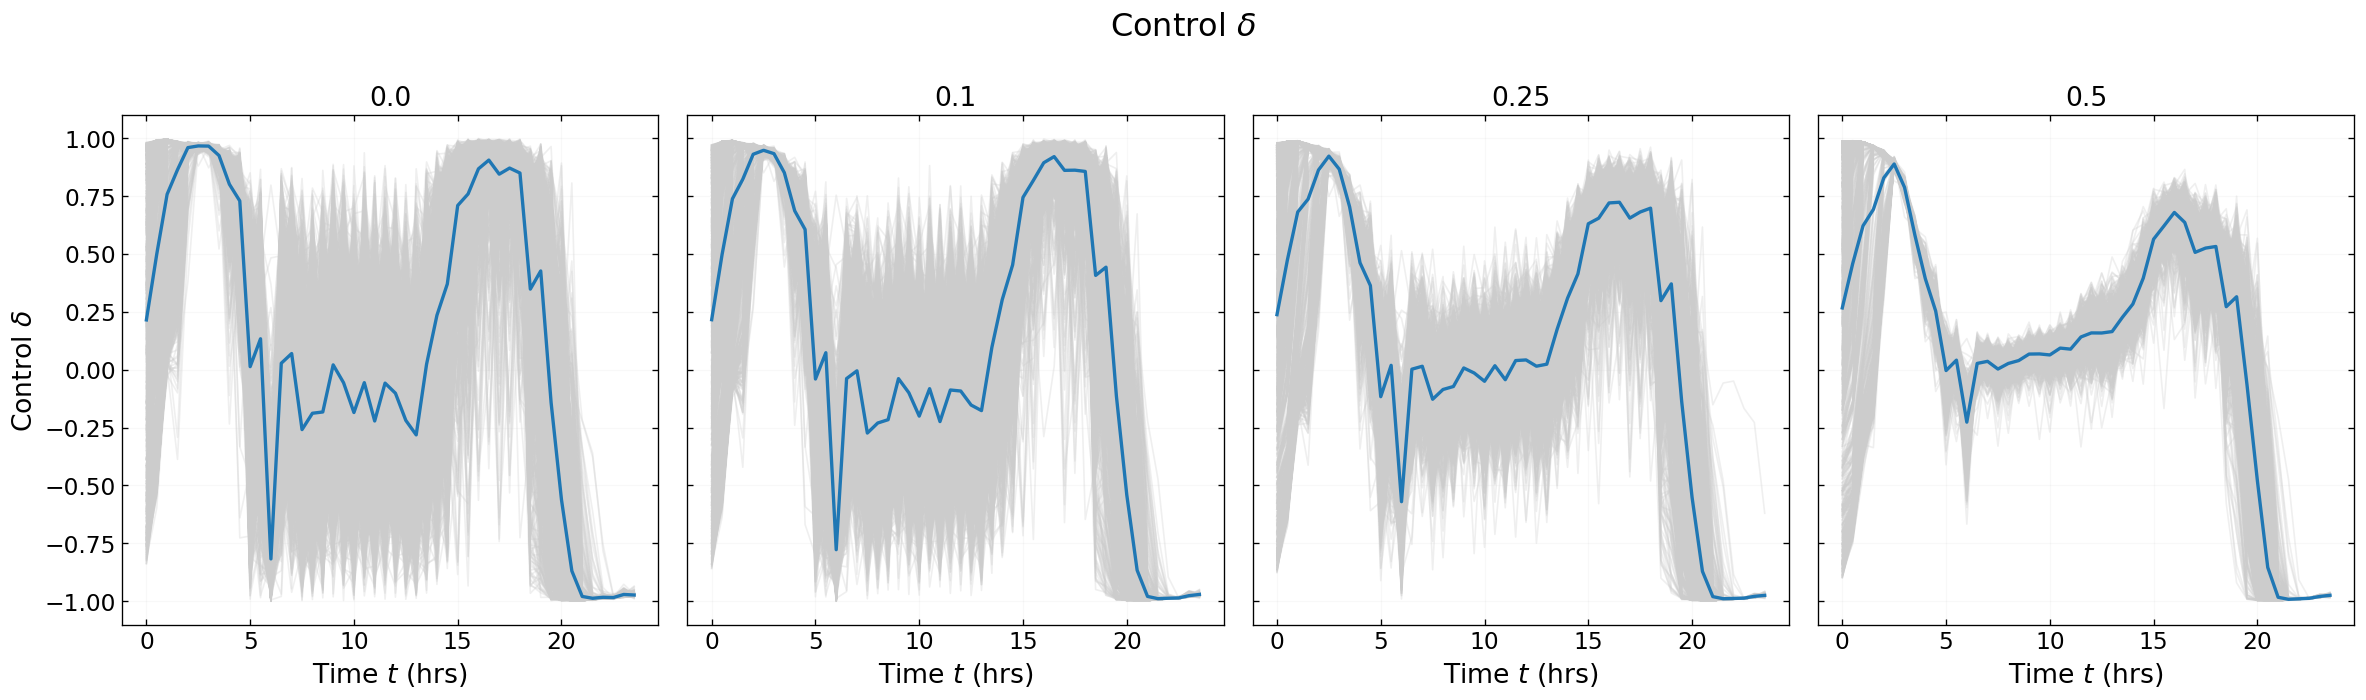

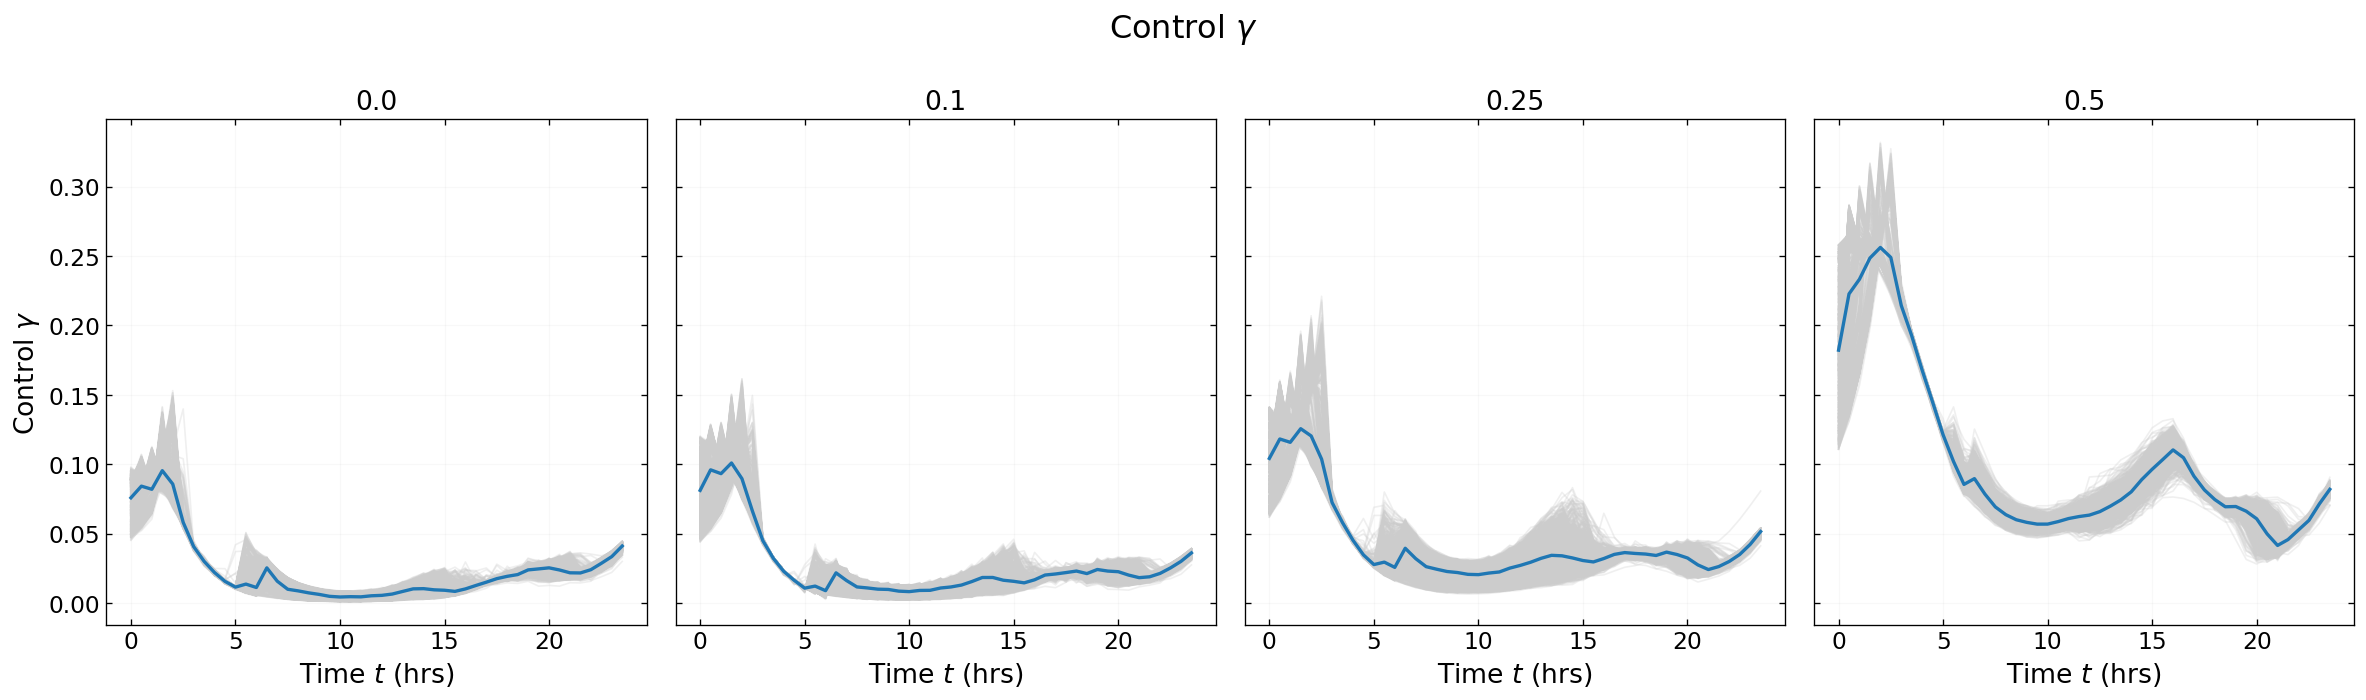

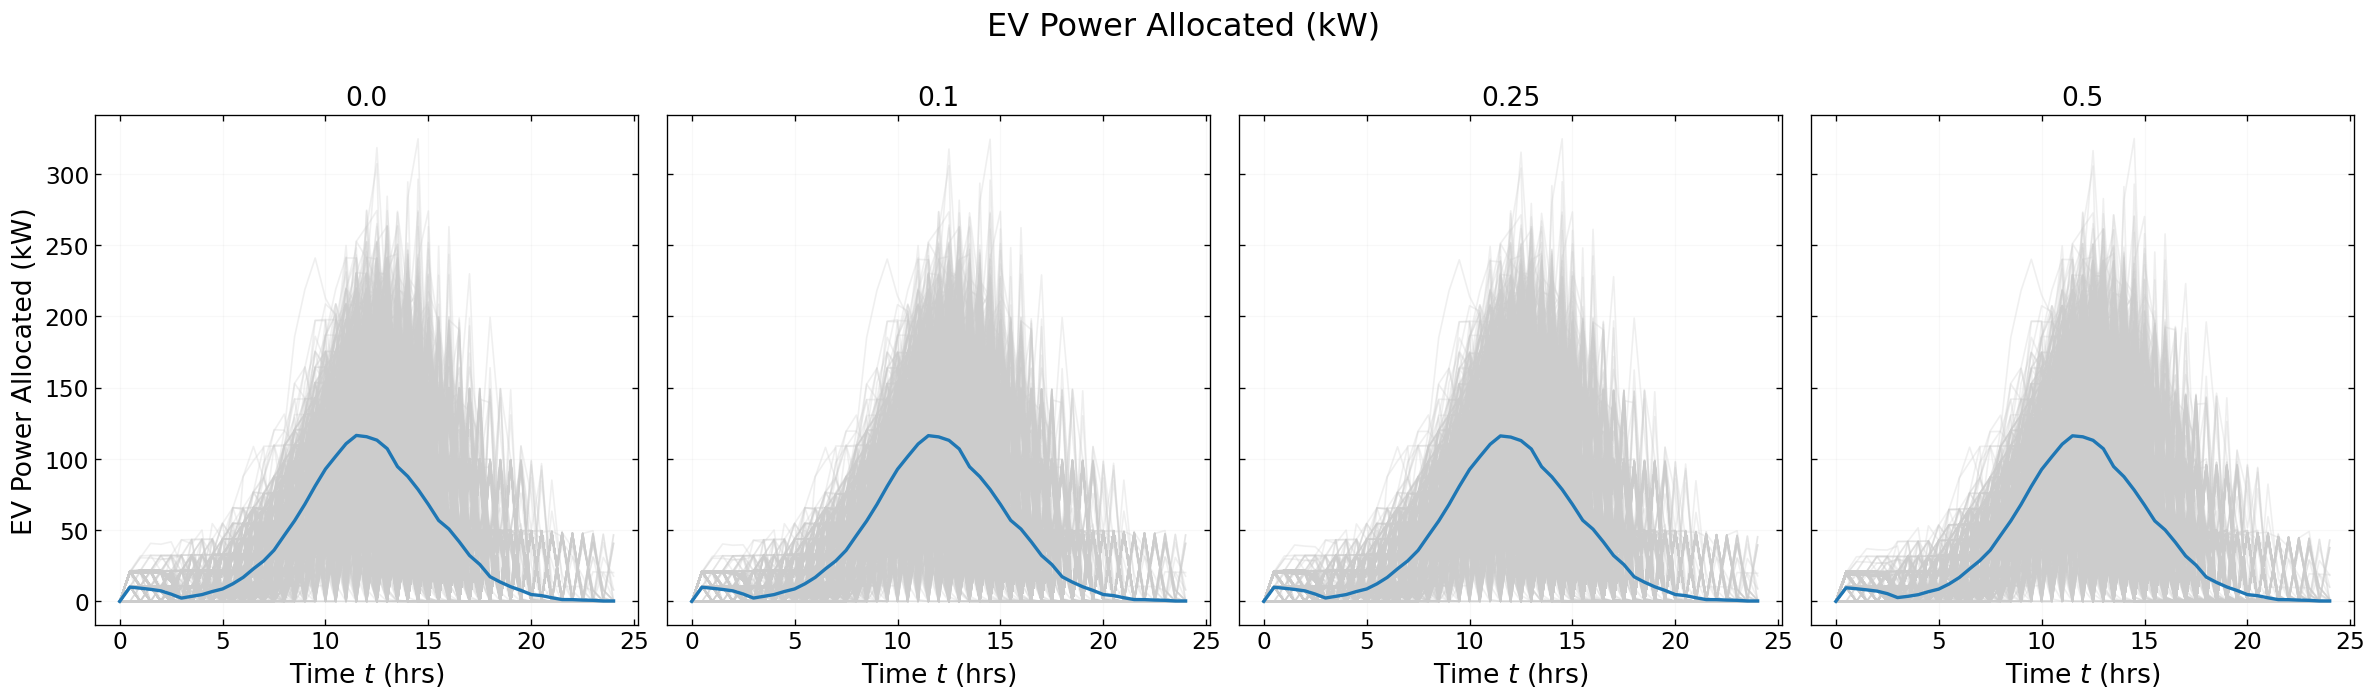

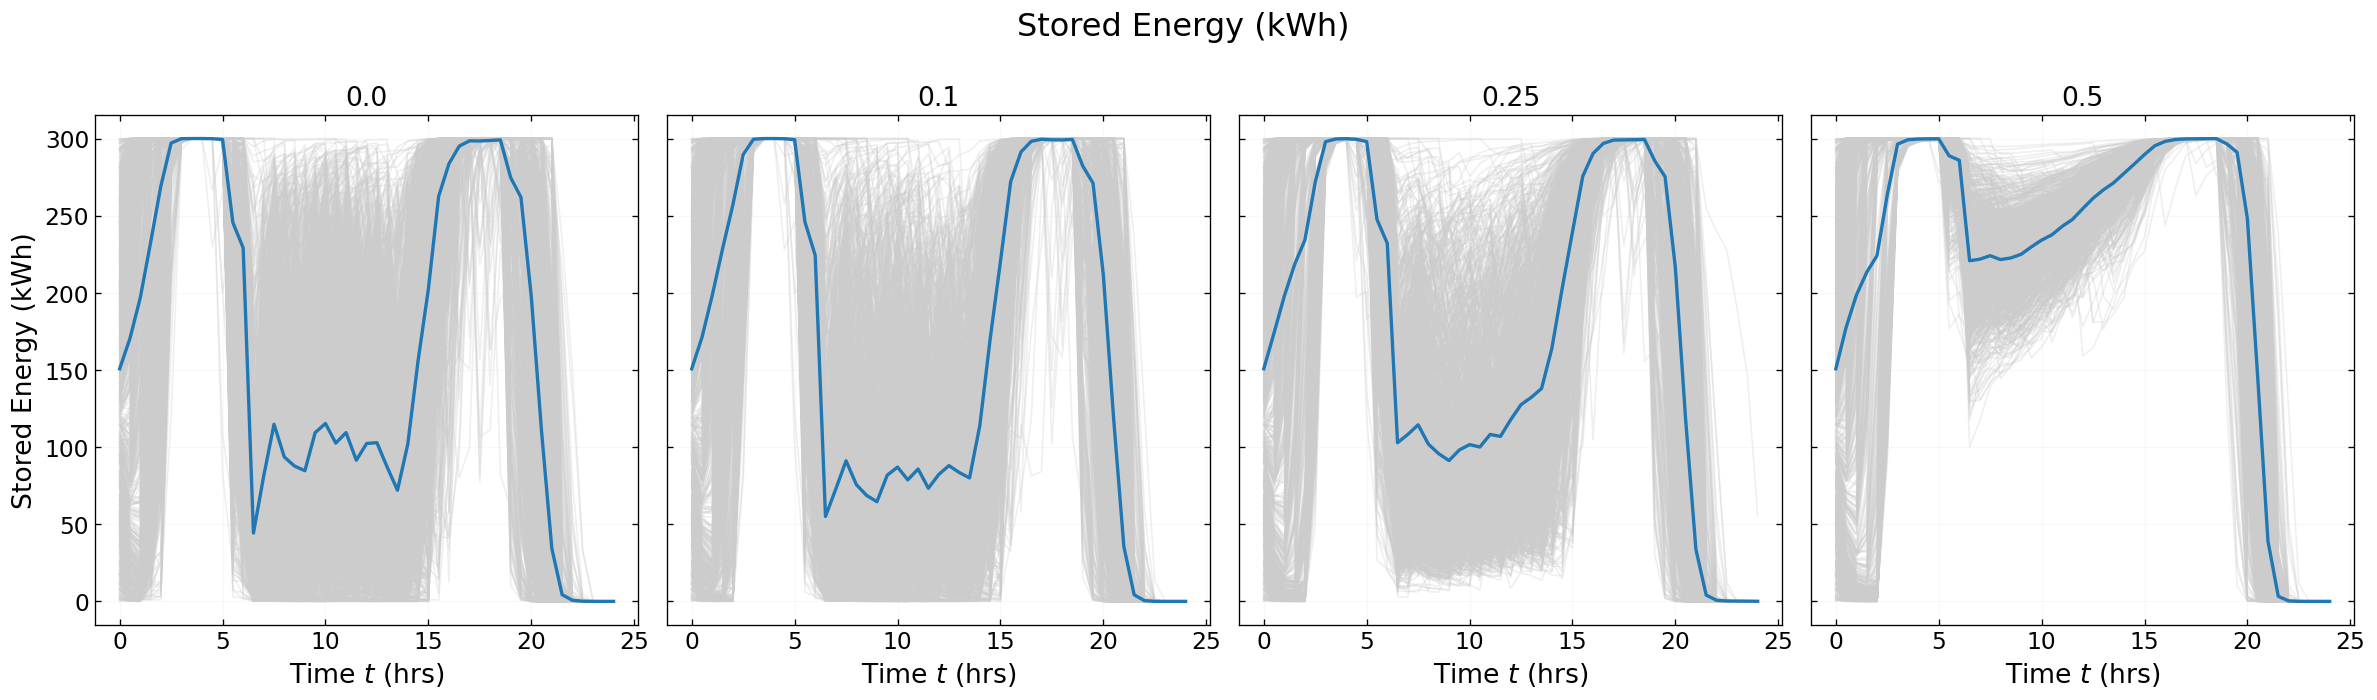

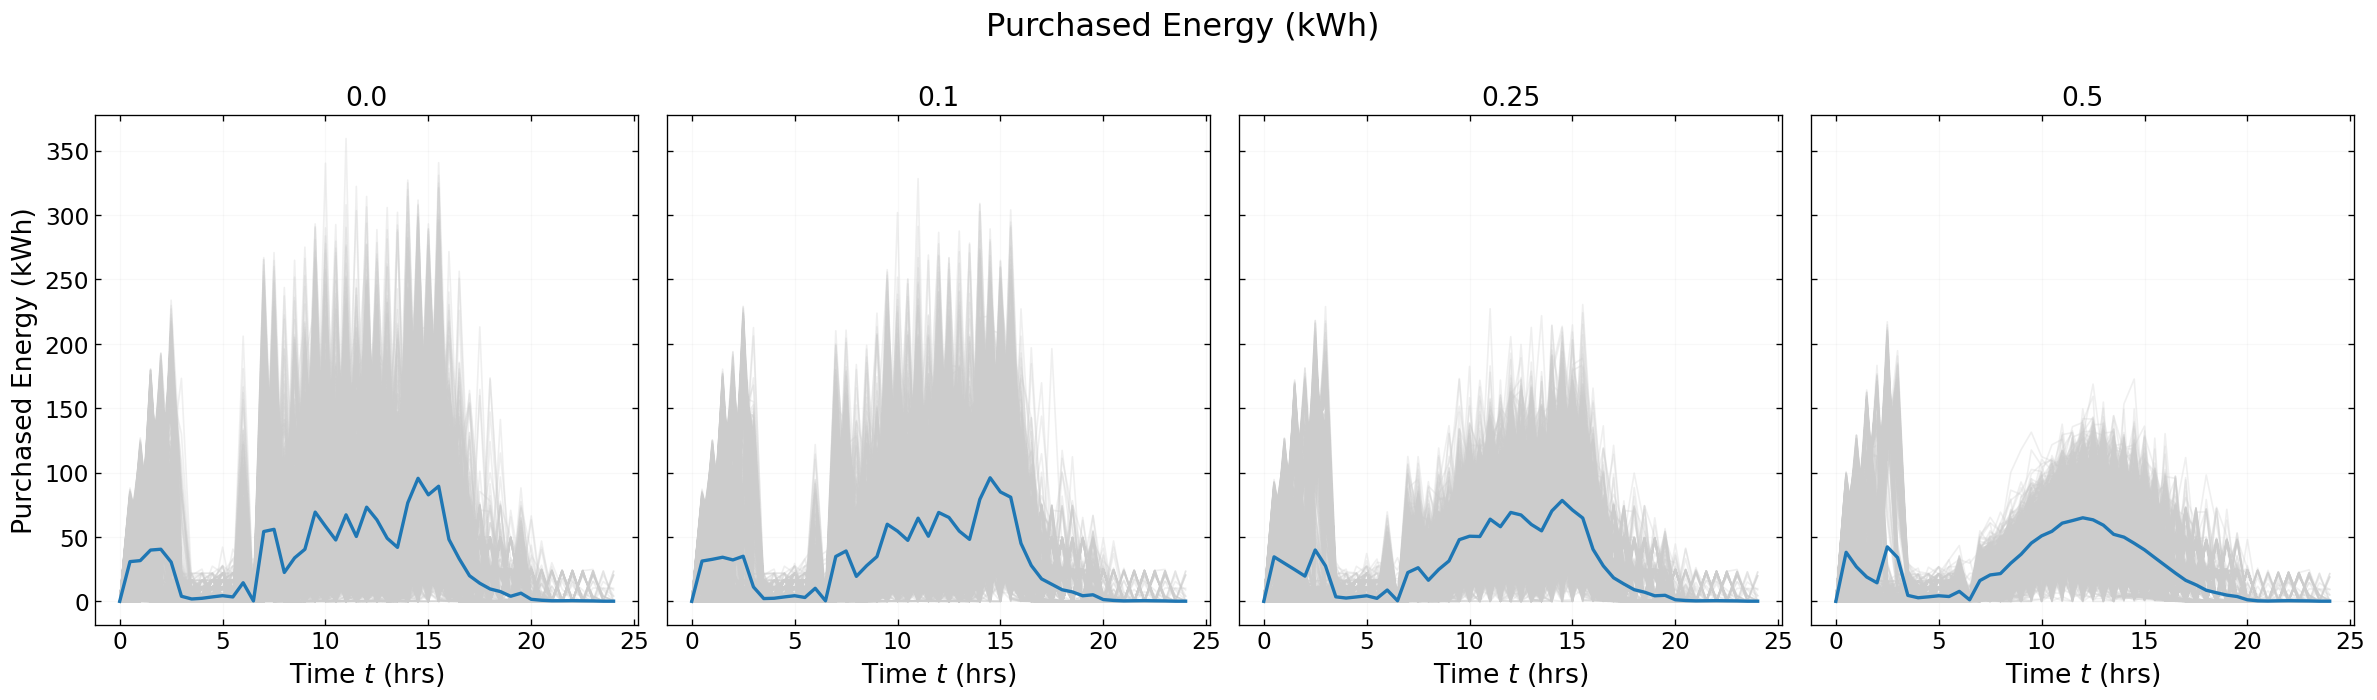

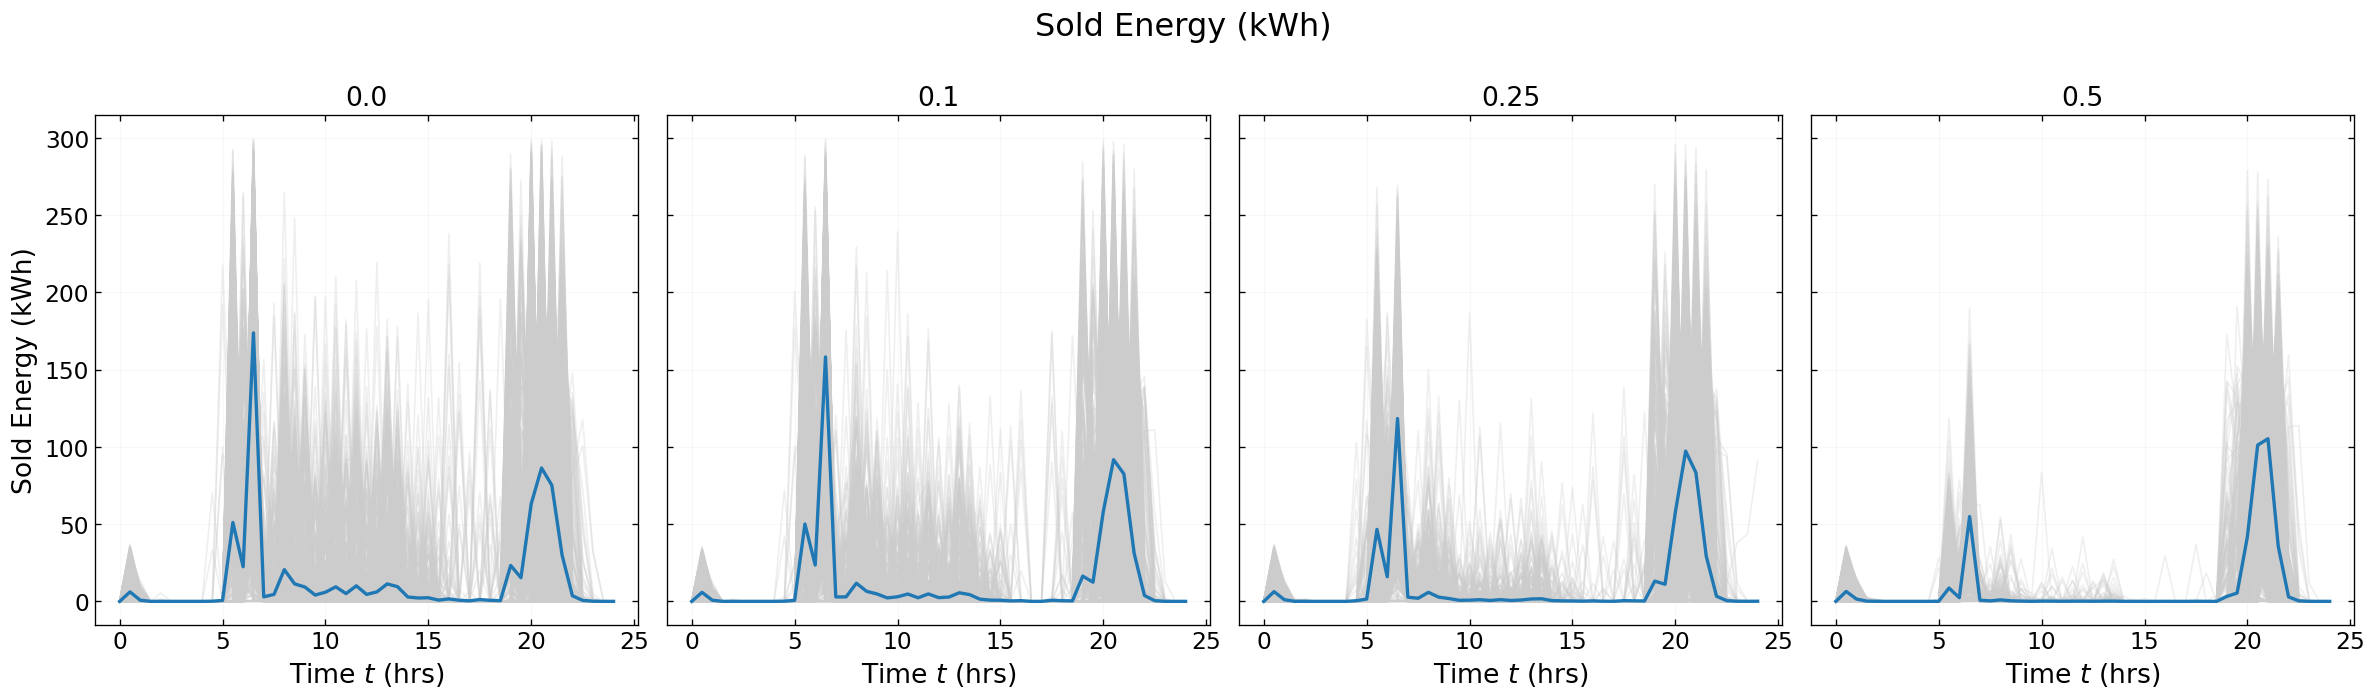

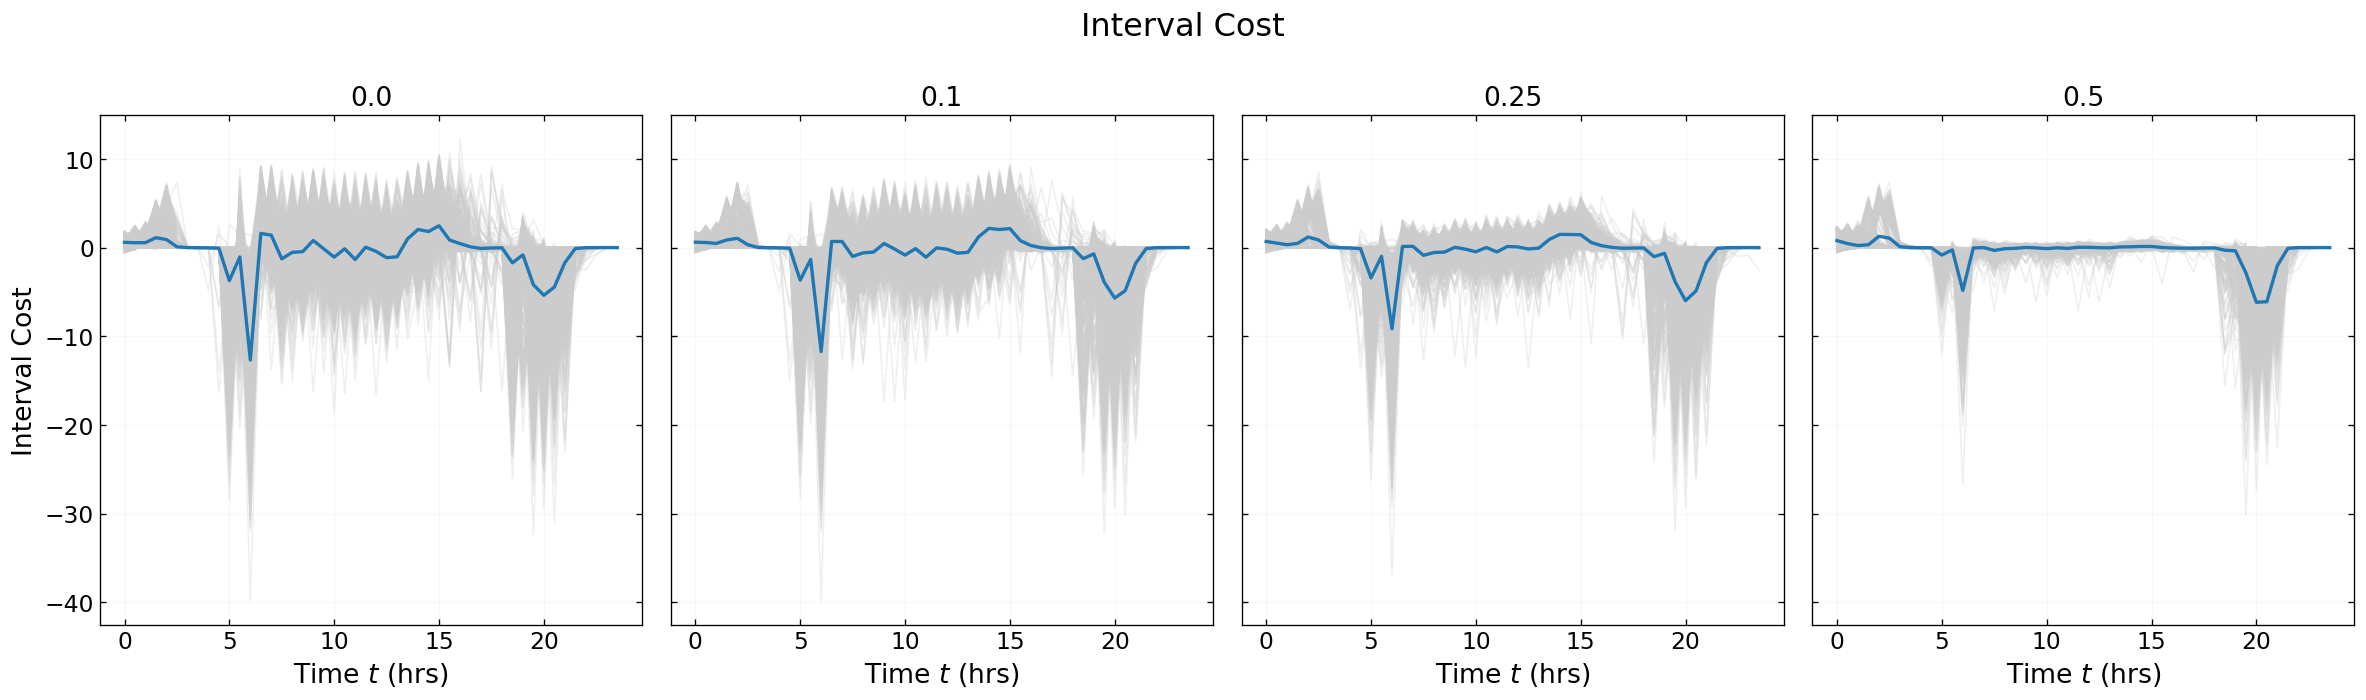

In [7]:

SAVE_DIR = "../figures/lambda_experiments"

plots = [
    ("eta",   r"Control $\eta$",             "control_eta.pdf"),
    ("delta", r"Control $\delta$",           "control_delta.pdf"),
    ("gamma", r"Control $\gamma$",           "control_gamma.pdf"),
    ("q",     "EV Power Allocated (kW)",     "ev_power_allocated.pdf"),
    ("E",     "Stored Energy (kWh)",         "stored_energy.pdf"),
    ("Ub",    "Purchased Energy (kWh)",      "purchased_energy.pdf"),
    ("Us",    "Sold Energy (kWh)",           "sold_energy.pdf"),
    ("c",     "Interval Cost",               "interval_cost.pdf"),
]

for key, ylabel, filename in plots:

    full_path = os.path.join(SAVE_DIR, filename)

    plot_variable_across_policies(
        rollout_results,
        key,
        ylabel,
        filename=full_path
    )

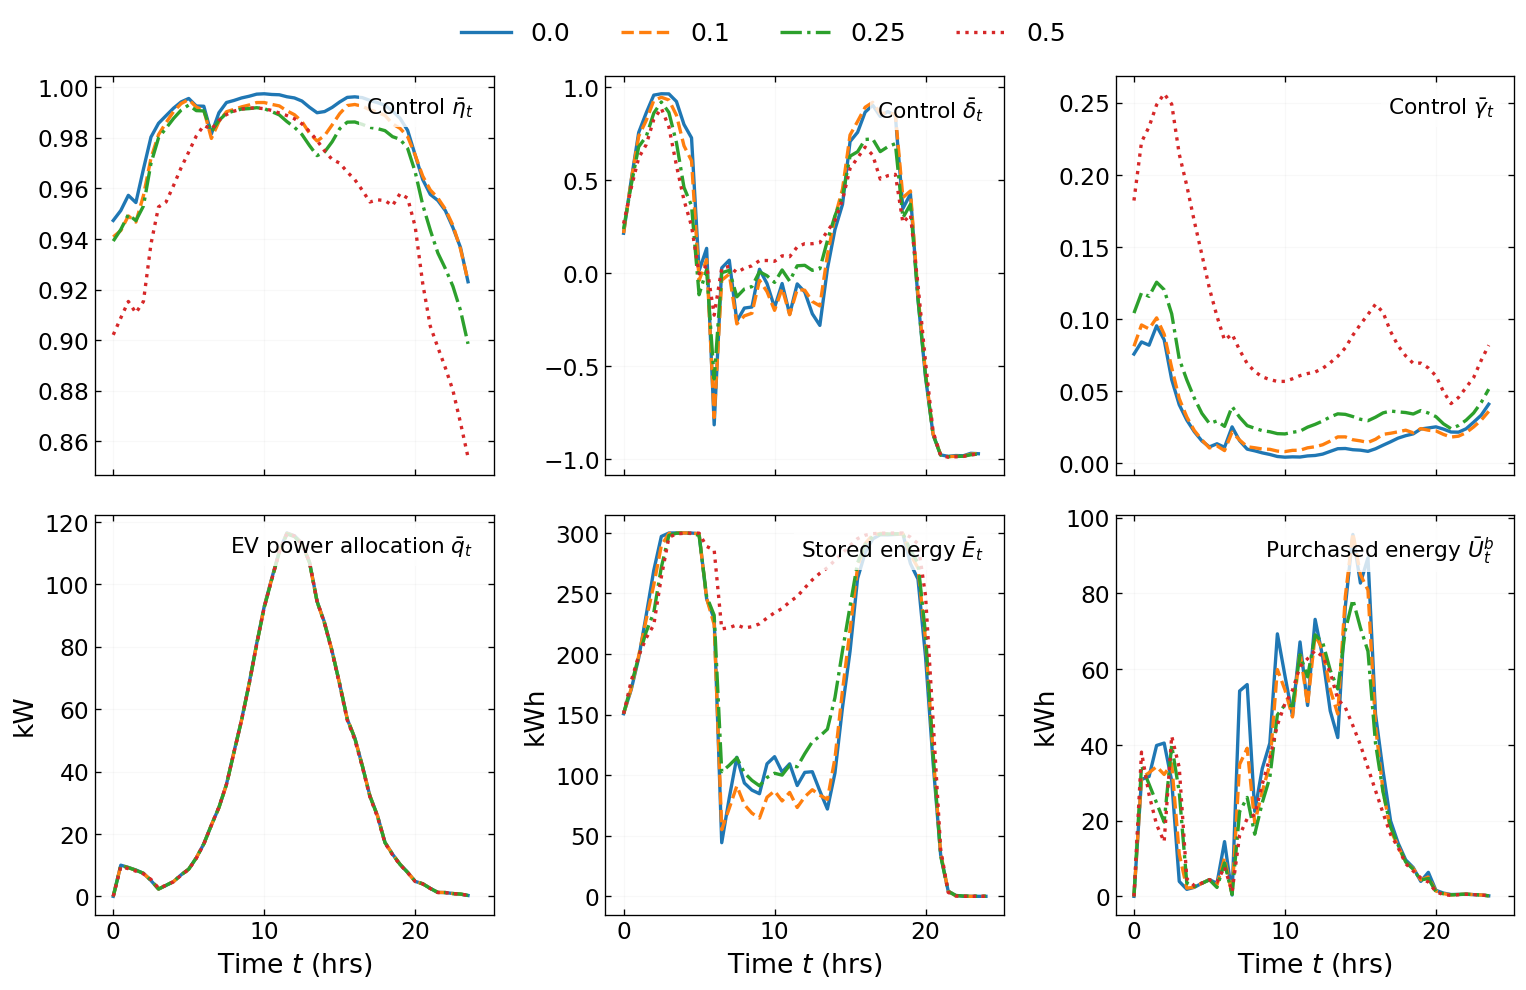

(<Figure size 1560x960 with 6 Axes>,
 array([<Axes: >, <Axes: >, <Axes: >,
        <Axes: xlabel='Time $t$ (hrs)', ylabel='kW'>,
        <Axes: xlabel='Time $t$ (hrs)', ylabel='kWh'>,
        <Axes: xlabel='Time $t$ (hrs)', ylabel='kWh'>], dtype=object))

In [8]:
plot_controls_summary(
    rollout_results,
    save_path="../figures/lambda_experiments/controls_summary.pdf"
)

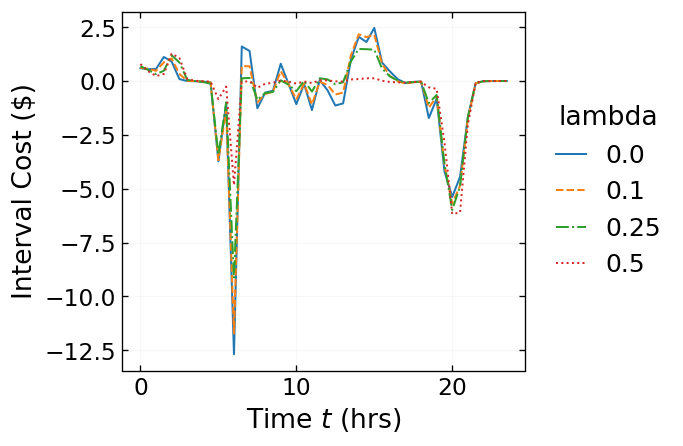

In [9]:
fig, ax = plt.subplots(figsize=(6, 4))

colors = {
    "0.0": "#1f77b4",
    "0.1": "#ff7f0e",
    "0.25": "#2ca02c",
    "0.5": "#d62728",
}

linestyles = {
    "0.0": "-",
    "0.1": "--",
    "0.25": "-.",
    "0.5": ":",
}

for lambda_, history in rollout_results.items():
    cost = history["cost"].detach().numpy()
    time = history["time"].detach().numpy()

    cost_mean = cost.mean(axis=1)

    ax.plot(
        time[:-1],
        cost_mean,
        color=colors.get(lambda_),
        ls=linestyles.get(lambda_),
        lw=1.2,
        label=lambda_,
    )

ax.set_xlabel(r"Time $t$ (hrs)")
ax.set_ylabel("Interval Cost ($)")

ax.legend(
    title="lambda",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
    handlelength=1.2
)

plt.tight_layout()
plt.savefig("../figures/lambda_experiments/cost_lambda_comparison.pdf")
plt.show()

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import cycle
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.legend_handler import HandlerTuple


def plot_policy_percentile_bands(
    results,
    metric_key,
    metric_idx=None,
    ax=None,
    policies=None,
    show_mean=True,
    add_legend=True,
    quantiles=(5, 95)
):

    if ax is None:
        _, ax = plt.subplots(figsize=(8, 4))

    colors = cycle([
        "tab:blue",
        "tab:orange",
        "tab:green",
        "tab:red",
        "tab:purple",
        "tab:brown",
    ])

    linestyles = cycle([
        "-",
        "--",
        "-.",
        ":",
        (0, (5, 1)),
        (0, (3, 1, 1, 1)),
    ])

    items = results.items()
    if policies is not None:
        items = [(k, results[k]) for k in policies]

    legend_handles = []
    legend_labels = []

    for key, res in items:

        color = next(colors)
        linestyle = next(linestyles)

        var = res[metric_key]
        time = res["time"]

        if metric_idx is not None:
            var = var[..., metric_idx]

        if len(time) != var.shape[0]:
            time = time[:var.shape[0]]

        mean = var.mean(axis=1)
        p1 = np.percentile(var, quantiles[0], axis=1)
        p2 = np.percentile(var, quantiles[1], axis=1)

        ax.fill_between(
            time, p1, p2, color=color, alpha=0.15
        )

        if show_mean:
            ax.plot(
                time, mean, color=color, linestyle=linestyle, linewidth=1.5
            )

            legend_handles.append(
                (
                    Patch(facecolor=color, alpha=0.15),
                    Line2D([0], [0], color=color, linestyle=linestyle, linewidth=1.5
                    ),
                )
            )
        else:
            legend_handles.append(
                Patch(facecolor=color, alpha=0.15)
            )

        legend_labels.append(key)

    if add_legend:
        ax.legend(
            legend_handles,
            legend_labels,
            handler_map={tuple: HandlerTuple(ndivide=1)},
            frameon=False,
        )

    return ax, legend_handles, legend_labels

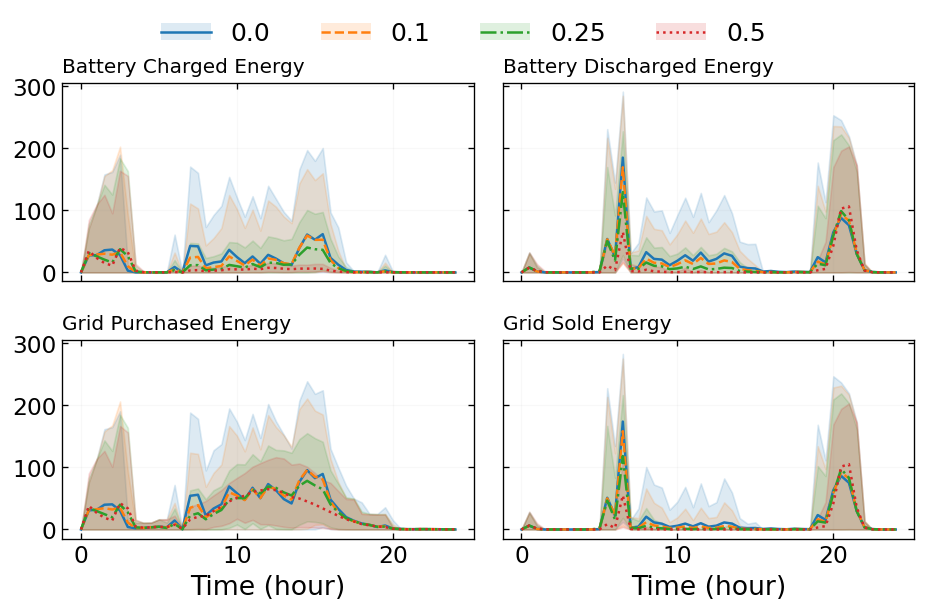

In [11]:
fig, axes = plt.subplots(2,2, sharex=True, sharey=True)

titles = (
    "EV Power Allocated",
    "Battery Charged Energy",
    "Battery Discharged Energy",
    "Grid Purchased Energy",
    "Grid Sold Energy"
)

for i, ax in enumerate(axes.flatten()):

    ax, handles, labels = plot_policy_percentile_bands(
        rollout_results, "endog", i+1, show_mean=True, ax=ax, add_legend=False
    )
    ax.set_title(titles[i+1], loc="left", size=12)
    if i > 1: ax.set_xlabel("Time (hour)")

fig.legend(
    handles,
    labels,
    handler_map={tuple: HandlerTuple(ndivide=1)},
    ncol=4,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.05),
    frameon=False
)

plt.tight_layout()
plt.show()

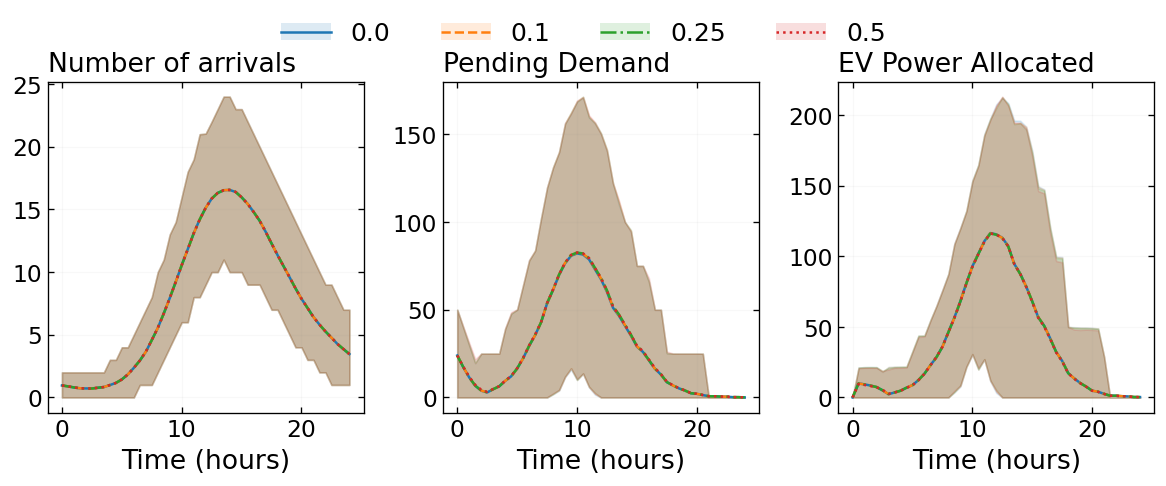

In [12]:

fig, ax = plt.subplots(1, 3, figsize=(10, 4))
ax = ax.flatten()

_, _ ,_ = plot_policy_percentile_bands(rollout_results, "state", 0, ax=ax[0], add_legend=False)
ax[0].set_title("Number of arrivals", loc="left")

_, _, _ = plot_policy_percentile_bands(rollout_results, "state", 1, ax=ax[1], add_legend=False)
ax[1].set_title("Pending Demand", loc="left")

_, handles, labels = plot_policy_percentile_bands(rollout_results, "endog", 0, ax=ax[2], add_legend=False)
ax[2].set_title("EV Power Allocated", loc="left")

fig.legend(
    handles,
    labels,
    handler_map={tuple: HandlerTuple(ndivide=1)},
    ncol=4,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.05),
    frameon=False
)

for a in ax:
    a.set_xlabel("Time (hours)")

plt.tight_layout()
plt.show()

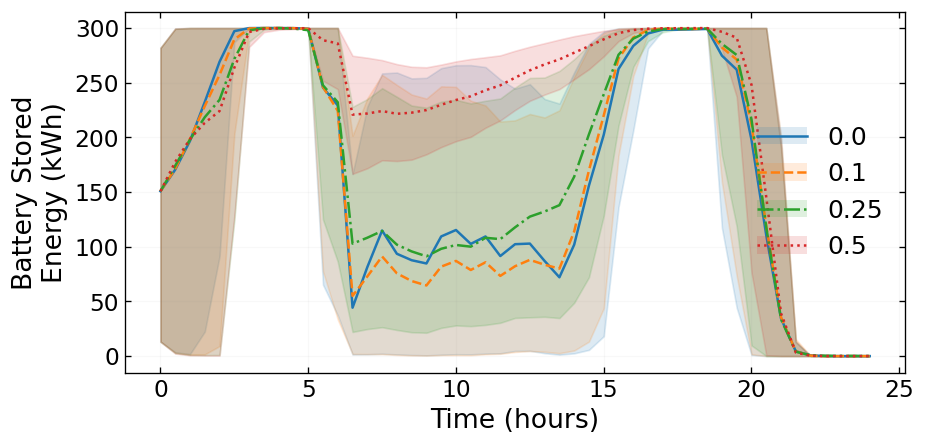

In [13]:
ax, _ ,_ = plot_policy_percentile_bands(rollout_results, "state", 2)

plt.xlabel("Time (hours)")
plt.ylabel("Battery Stored\nEnergy (kWh)")
plt.tight_layout()
plt.show()

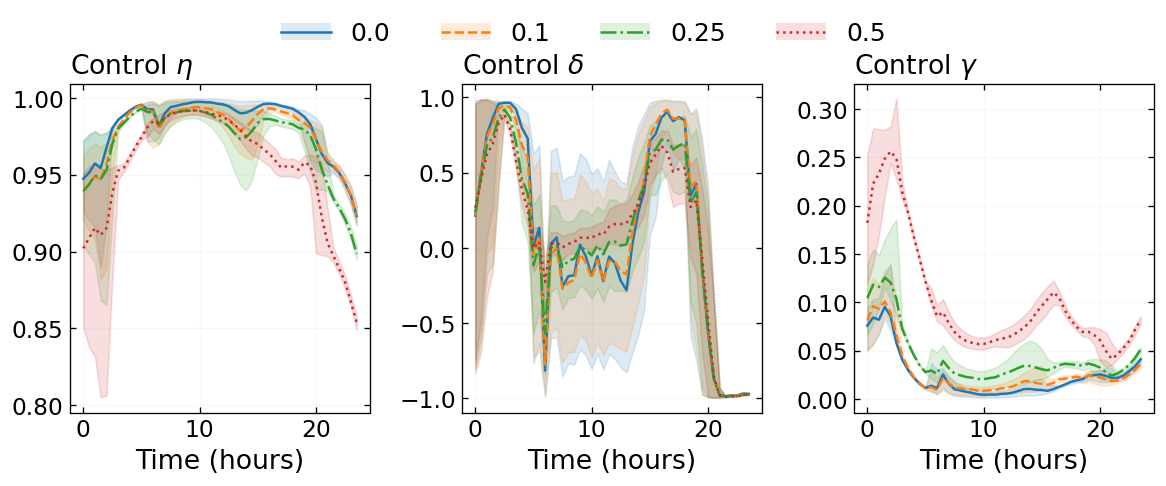

In [14]:
fig, axes = plt.subplots(1, 3, sharex=True, figsize=(10,4))

titles = (
    "Control $\eta$", "Control $\delta$", "Control $\gamma$"
)

for i, ax in enumerate(axes.flatten()):
    ax, _ ,_ = plot_policy_percentile_bands(rollout_results, "control", i, ax=ax, add_legend=False)
    ax.set_xlabel("Time (hours)")
    ax.set_title(titles[i], loc="left")

fig.legend(
    handles,
    labels,
    handler_map={tuple: HandlerTuple(ndivide=1)},
    ncol=4,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.05),
    frameon=False
)

plt.tight_layout()
plt.show()

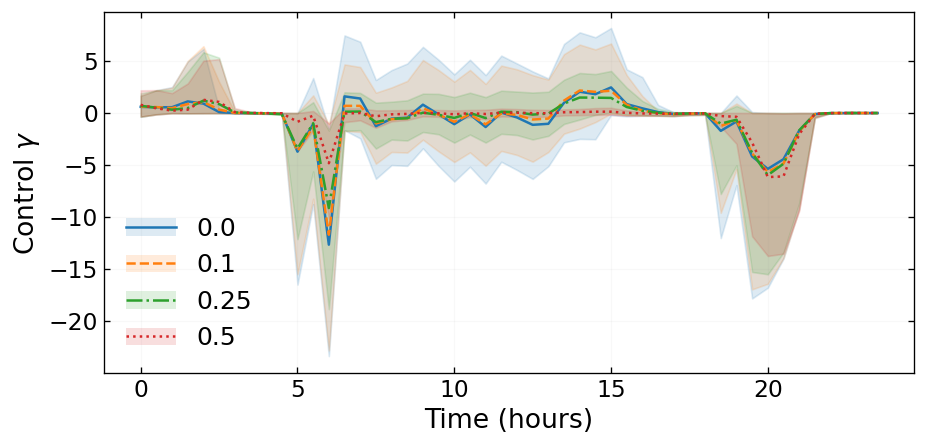

In [15]:
ax, _ ,_ = plot_policy_percentile_bands(rollout_results, "cost")

plt.xlabel("Time (hours)")
plt.ylabel("Control $\gamma$")
plt.tight_layout()
plt.show()

In [16]:
from source.utils import summarize_histories

df = summarize_histories(rollout_results)
print(df.round(4))

                 0.0       0.1      0.25       0.5
N_mean        7.6744    7.6744    7.6744    7.6744
N_std         6.1878    6.1878    6.1878    6.1878
D_mean       27.3978   27.5254   27.6031   27.6840
D_std        37.9865   38.1177   38.1934   38.1641
E_mean      164.6873  161.6361  172.7858  221.3405
E_std       125.6616  127.0083  118.9606  106.9430
P_mean        0.0420    0.0420    0.0420    0.0420
P_std         0.0157    0.0157    0.0157    0.0157
eta_mean      0.9817    0.9778    0.9720    0.9539
eta_std       0.0212    0.0211    0.0271    0.0409
delta_mean    0.1053    0.0997    0.0886    0.1030
delta_std     0.7145    0.6933    0.6119    0.5608
gamma_mean    0.0240    0.0268    0.0428    0.1022
gamma_std     0.0242    0.0257    0.0308    0.0621
q_mean       36.6138   36.5667   36.5290   36.4621
q_std        51.0668   50.9123   50.7941   50.7466
ec_mean      15.3116   12.8667    9.7200    5.2079
ec_std       37.7503   32.5323   23.6791   18.5540
ed_mean      18.3883   15.9435 

In [17]:
import os

SAVE_DIR = "../checkpoints/rollouts"
os.makedirs(SAVE_DIR, exist_ok=True)

df.to_csv(
    os.path.join(
        SAVE_DIR,
        "lambda_experiment_summary.csv"
    )
)

with open(
    os.path.join(
        SAVE_DIR,
        "lambda_experiment_summary.tex"
    ),
    "w"
) as f:
    f.write(df.round(4).to_latex())

print(df.round(4))

                 0.0       0.1      0.25       0.5
N_mean        7.6744    7.6744    7.6744    7.6744
N_std         6.1878    6.1878    6.1878    6.1878
D_mean       27.3978   27.5254   27.6031   27.6840
D_std        37.9865   38.1177   38.1934   38.1641
E_mean      164.6873  161.6361  172.7858  221.3405
E_std       125.6616  127.0083  118.9606  106.9430
P_mean        0.0420    0.0420    0.0420    0.0420
P_std         0.0157    0.0157    0.0157    0.0157
eta_mean      0.9817    0.9778    0.9720    0.9539
eta_std       0.0212    0.0211    0.0271    0.0409
delta_mean    0.1053    0.0997    0.0886    0.1030
delta_std     0.7145    0.6933    0.6119    0.5608
gamma_mean    0.0240    0.0268    0.0428    0.1022
gamma_std     0.0242    0.0257    0.0308    0.0621
q_mean       36.6138   36.5667   36.5290   36.4621
q_std        51.0668   50.9123   50.7941   50.7466
ec_mean      15.3116   12.8667    9.7200    5.2079
ec_std       37.7503   32.5323   23.6791   18.5540
ed_mean      18.3883   15.9435 